# Évaluation méthodologique d’un système RAG

**Sous-titre :** ce notebook analyse les résultats d’évaluation **et** la solidité de leur interprétation, afin de produire une lecture défendable en soutenance, audit ou mémoire.


## Introduction méthodologique

Ce notebook a pour objectif d’examiner les performances d’un système RAG à partir d’un fichier `ragas_details_*.csv`, tout en explicitant les conditions de validité des conclusions. L’enjeu n’est pas seulement de produire des graphiques, mais de clarifier ce que les métriques permettent réellement d’affirmer.

Ce qui est évalué ici couvre plusieurs dimensions : qualité de réponse (métriques RAGAS cœur), qualité de récupération (métriques retrieval), et contraintes opérationnelles (latence, tokens, coût quand disponible). Ces dimensions sont complémentaires, mais ne mesurent pas la même chose.

Les métriques observées doivent être lues comme des indicateurs partiels. Elles dépendent des données disponibles, des références utilisées, et du protocole de calcul. En conséquence, un score élevé n’implique pas automatiquement une robustesse générale sur tous les cas possibles.

Un score de 1 signifie un résultat maximal selon la définition de la métrique et les données de comparaison disponibles, pas une perfection absolue dans tous les sens possibles.

La démarche adoptée est donc double : (1) décrire les résultats, puis (2) questionner la portée des résultats, leurs limites, et les biais potentiels d’interprétation.


In [70]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

csv_candidates = sorted(Path('outputs/evaluations').glob('ragas_details_*.csv'))
if not csv_candidates:
    raise FileNotFoundError("Aucun fichier ragas_details_*.csv trouvé dans outputs/evaluations")

csv_path = csv_candidates[-1]
df = pd.read_csv(csv_path)

n_obs, n_cols = df.shape
print(f"Fichier chargé : {csv_path}")
print(f"Nombre d'observations : {n_obs}")
print(f"Nombre de colonnes : {n_cols}")

metric_groups = {
    'ragas_core': ['answer_relevancy', 'faithfulness', 'context_precision', 'context_recall'],
    'retrieval': ['retrieval_precision_at_k', 'retrieval_recall_at_k', 'retrieval_mrr', 'retrieval_ndcg_at_k', 'retrieval_keyword_coverage', 'retrieval_keywords_count'],
    'operational': ['latency_retrieval_s', 'latency_generation_s', 'latency_total_s', 'input_tokens', 'output_tokens', 'total_tokens'],
}

def existing(cols):
    return [c for c in cols if c in df.columns]

available_metrics = {k: existing(v) for k, v in metric_groups.items()}
all_metrics = [m for group in available_metrics.values() for m in group]
all_metrics = list(dict.fromkeys(all_metrics))

id_col = 'id' if 'id' in df.columns else None
category_col = 'category' if 'category' in df.columns else None

display(df.head())


Fichier chargé : outputs/evaluations/ragas_details_20260314_153334.csv
Nombre d'observations : 11
Nombre de colonnes : 23


,sample_index,id,category,user_input,retrieved_contexts,response,reference,answer_relevancy,faithfulness,context_precision,...,latency_total_s,input_tokens,output_tokens,total_tokens,retrieval_precision_at_k,retrieval_recall_at_k,retrieval_mrr,retrieval_ndcg_at_k,retrieval_keyword_coverage,retrieval_keywords_count
0,0,q1,simple,Quel est le nom complet de l'équipe codée OKC ?,"[""Code Nom complet de l'équipe 0 ATL Atlanta H...",Oklahoma City Thunder,OKC correspond à Oklahoma City Thunder.,0.757956,1.0,1.0,...,2.107763,1175,5,1180,0.6,1.0,1.0,1.0,1.0,2
1,1,q2,simple,"Selon le tableau des équipes, combien de point...","[""4 Code Nom complet de l'équipe Nombre de jou...","Selon le contexte fourni, OKC (Oklahoma City T...",OKC totalise 9880 points.,0.818908,1.0,1.0,...,2.131373,841,25,866,0.6,1.0,1.0,1.0,1.0,2
2,2,q3,complex,"Parmi MIA, OKC, LAC et BKN, quelle équipe a le...","[""4 Code Nom complet de l'équipe Nombre de jou...",OKC Oklahoma City Thunder avec 9880 points tot...,"Parmi ces quatre équipes, OKC est premier avec...",0.756804,1.0,1.0,...,2.002747,830,16,846,0.6,1.0,1.0,1.0,1.0,5
3,3,q4,complex,Quelle est la différence de points totaux entr...,"[""4 Code Nom complet de l'équipe Nombre de jou...",La différence de points totaux entre OKC (9880...,La différence est de 52 points.,0.977208,1.0,1.0,...,2.530002,1062,32,1094,0.6,0.8,1.0,1.0,0.8,5
4,4,q5,simple,Combien de joueurs compte l'équipe Brooklyn Ne...,"[""Code Nom complet de l'équipe 0 ATL Atlanta H...",L'équipe Brooklyn Nets (BKN) compte 20 joueurs.,BKN compte 20 joueurs.,0.992126,1.0,0.5,...,1.974237,687,15,702,0.6,1.0,1.0,1.0,1.0,3


In [71]:
# Vérification de structure et disponibilité des données
expected_columns = [
    'id', 'category', 'user_input', 'reference', 'response',
    'answer_relevancy', 'faithfulness', 'context_precision', 'context_recall',
    'retrieval_precision_at_k', 'retrieval_recall_at_k', 'retrieval_mrr', 'retrieval_ndcg_at_k',
    'latency_retrieval_s', 'latency_generation_s', 'latency_total_s',
    'input_tokens', 'output_tokens', 'total_tokens'
]

rows = []
for col in sorted(df.columns):
    nn = int(df[col].notna().sum())
    total = len(df)
    nn_ratio = (nn / total) if total else 0.0
    rows.append({
        'colonne': col,
        'attendue': col in expected_columns,
        'presente': True,
        'non_null_count': nn,
        'non_null_ratio': nn_ratio,
        'totalement_vide': nn == 0,
        'partiellement_renseignee': 0 < nn < total,
        'dtype': str(df[col].dtype),
    })

for col in expected_columns:
    if col not in df.columns:
        rows.append({
            'colonne': col,
            'attendue': True,
            'presente': False,
            'non_null_count': 0,
            'non_null_ratio': 0.0,
            'totalement_vide': True,
            'partiellement_renseignee': False,
            'dtype': 'ABSENTE',
        })

structure_df = pd.DataFrame(rows).sort_values(['presente', 'attendue', 'colonne'], ascending=[False, False, True])

display(structure_df)

print('\nColonnes attendues absentes :')
missing_expected = structure_df[(structure_df['attendue']) & (~structure_df['presente'])]['colonne'].tolist()
print(missing_expected if missing_expected else 'Aucune')

print('\nColonnes totalement vides :')
empty_cols = structure_df[(structure_df['presente']) & (structure_df['totalement_vide'])]['colonne'].tolist()
print(empty_cols if empty_cols else 'Aucune')

print('\nColonnes partiellement renseignées :')
partial_cols = structure_df[(structure_df['presente']) & (structure_df['partiellement_renseignee'])]['colonne'].tolist()
print(partial_cols if partial_cols else 'Aucune')


,colonne,attendue,presente,non_null_count,non_null_ratio,totalement_vide,partiellement_renseignee,dtype
0,answer_relevancy,True,True,11,1.0,False,False,float64
1,category,True,True,11,1.0,False,False,object
2,context_precision,True,True,11,1.0,False,False,float64
3,context_recall,True,True,11,1.0,False,False,float64
4,faithfulness,True,True,11,1.0,False,False,float64
5,id,True,True,11,1.0,False,False,object
6,input_tokens,True,True,11,1.0,False,False,int64
7,latency_generation_s,True,True,11,1.0,False,False,float64
8,latency_retrieval_s,True,True,11,1.0,False,False,float64
9,latency_total_s,True,True,11,1.0,False,False,float64



Colonnes attendues absentes :
Aucune

Colonnes totalement vides :
Aucune

Colonnes partiellement renseignées :
Aucune


### Pourquoi cette étape est méthodologiquement nécessaire

L’interprétation d’une métrique suppose d’abord que la colonne correspondante existe et soit renseignée. Une métrique absente ou vide ne doit pas être interprétée comme un “mauvais résultat”, mais comme une **limite de périmètre** de l’évaluation.

Le taux de disponibilité des colonnes conditionne donc la robustesse des conclusions : plus la complétude est faible, plus les conclusions doivent être prudentes et circonscrites.


## Cadre d’interprétation des métriques

Toutes les métriques ne comparent pas les mêmes objets. Certaines comparent réponse et contexte, d’autres réponse et référence, d’autres encore évaluent la qualité du retrieval. Une lecture défendable exige de clarifier ce comparateur avant d’interpréter un score.


In [72]:
# Tableau de cadrage méthodologique des métriques
metric_frame = [
    {
        'metrique': 'answer_relevancy',
        'ce_qui_est_mesure': 'Pertinence de la réponse vis-à-vis de la question',
        'reference_ou_comparateur': 'Question + jugement LLM',
        'ce_qu_un_score_eleve_suggere': 'Réponse alignée avec l’intention de la question',
        'limite_principale': 'N’atteste pas, à elle seule, la vérité factuelle absolue'
    },
    {
        'metrique': 'faithfulness',
        'ce_qui_est_mesure': 'Fidélité de la réponse au contexte récupéré',
        'reference_ou_comparateur': 'Réponse vs contexts',
        'ce_qu_un_score_eleve_suggere': 'Réponse soutenue par les passages fournis',
        'limite_principale': 'Une réponse fidèle à un contexte incomplet peut rester inexacte dans l’absolu'
    },
    {
        'metrique': 'context_precision',
        'ce_qui_est_mesure': 'Proportion de contexte utile dans ce qui est récupéré',
        'reference_ou_comparateur': 'Contexts vs question/réponse/référence selon métrique',
        'ce_qu_un_score_eleve_suggere': 'Peu de bruit dans les passages récupérés',
        'limite_principale': 'Ne suffit pas à garantir la qualité de la réponse finale'
    },
    {
        'metrique': 'context_recall',
        'ce_qui_est_mesure': 'Couverture des éléments pertinents dans les contexts',
        'reference_ou_comparateur': 'Contexts vs référence',
        'ce_qu_un_score_eleve_suggere': 'Le retrieval couvre bien les éléments attendus',
        'limite_principale': 'Dépend fortement de la qualité de la référence'
    },
    {
        'metrique': 'retrieval_precision_at_k',
        'ce_qui_est_mesure': 'Part de résultats pertinents dans le top-k',
        'reference_ou_comparateur': 'Règle de pertinence retrieval (proxy du notebook)',
        'ce_qu_un_score_eleve_suggere': 'Top-k plutôt propre et ciblé',
        'limite_principale': 'Évalue le retrieval, pas directement l’utilité métier finale'
    },
    {
        'metrique': 'retrieval_recall_at_k',
        'ce_qui_est_mesure': 'Capacité à couvrir les éléments pertinents dans le top-k',
        'reference_ou_comparateur': 'Règle de pertinence retrieval (proxy du notebook)',
        'ce_qu_un_score_eleve_suggere': 'Bonne couverture des informations utiles',
        'limite_principale': 'Un recall élevé peut coexister avec beaucoup de bruit'
    },
    {
        'metrique': 'retrieval_mrr',
        'ce_qui_est_mesure': 'Position du premier résultat pertinent',
        'reference_ou_comparateur': 'Classement retrieval',
        'ce_qu_un_score_eleve_suggere': 'Le premier résultat utile arrive tôt',
        'limite_principale': 'Ne renseigne pas sur la qualité des résultats suivants'
    },
    {
        'metrique': 'retrieval_ndcg_at_k',
        'ce_qui_est_mesure': 'Qualité globale de l’ordre des résultats',
        'reference_ou_comparateur': 'Classement retrieval avec gain décroissant',
        'ce_qu_un_score_eleve_suggere': 'Bon ordonnancement des documents pertinents',
        'limite_principale': 'Reste une métrique de ranking, pas une validation métier complète'
    },
]

interp_df = pd.DataFrame(metric_frame)
interp_df['disponible_dans_ce_run'] = interp_df['metrique'].isin(df.columns)
interp_df['statut'] = np.where(interp_df['disponible_dans_ce_run'], 'Disponible', 'Absente / non calculable ici')

display(interp_df)


,metrique,ce_qui_est_mesure,reference_ou_comparateur,ce_qu_un_score_eleve_suggere,limite_principale,disponible_dans_ce_run,statut
0,answer_relevancy,Pertinence de la réponse vis-à-vis de la question,Question + jugement LLM,Réponse alignée avec l’intention de la question,"N’atteste pas, à elle seule, la vérité factuel...",True,Disponible
1,faithfulness,Fidélité de la réponse au contexte récupéré,Réponse vs contexts,Réponse soutenue par les passages fournis,Une réponse fidèle à un contexte incomplet peu...,True,Disponible
2,context_precision,Proportion de contexte utile dans ce qui est r...,Contexts vs question/réponse/référence selon m...,Peu de bruit dans les passages récupérés,Ne suffit pas à garantir la qualité de la répo...,True,Disponible
3,context_recall,Couverture des éléments pertinents dans les co...,Contexts vs référence,Le retrieval couvre bien les éléments attendus,Dépend fortement de la qualité de la référence,True,Disponible
4,retrieval_precision_at_k,Part de résultats pertinents dans le top-k,Règle de pertinence retrieval (proxy du notebook),Top-k plutôt propre et ciblé,"Évalue le retrieval, pas directement l’utilité...",True,Disponible
5,retrieval_recall_at_k,Capacité à couvrir les éléments pertinents dan...,Règle de pertinence retrieval (proxy du notebook),Bonne couverture des informations utiles,Un recall élevé peut coexister avec beaucoup d...,True,Disponible
6,retrieval_mrr,Position du premier résultat pertinent,Classement retrieval,Le premier résultat utile arrive tôt,Ne renseigne pas sur la qualité des résultats ...,True,Disponible
7,retrieval_ndcg_at_k,Qualité globale de l’ordre des résultats,Classement retrieval avec gain décroissant,Bon ordonnancement des documents pertinents,"Reste une métrique de ranking, pas une validat...",True,Disponible


## Complétude des métriques : condition de validité minimale

Cette section vérifie que les métriques sont effectivement observables. Si une dimension est absente ou massivement manquante, la conclusion sur cette dimension doit être suspendue.


,na_ratio,non_null_count,non_null_ratio
answer_relevancy,0.0,11,1.0
faithfulness,0.0,11,1.0
context_precision,0.0,11,1.0
context_recall,0.0,11,1.0
retrieval_precision_at_k,0.0,11,1.0
retrieval_recall_at_k,0.0,11,1.0
retrieval_mrr,0.0,11,1.0
retrieval_ndcg_at_k,0.0,11,1.0
retrieval_keyword_coverage,0.0,11,1.0
retrieval_keywords_count,0.0,11,1.0


,count,mean,std,min,25%,50%,75%,max
answer_relevancy,11.0,0.848540,0.134915,0.626162,0.757380,0.930813,0.950284,0.992126
faithfulness,11.0,0.954545,0.150756,0.500000,1.000000,1.000000,1.000000,1.000000
context_precision,11.0,0.840909,0.280016,0.250000,0.750000,1.000000,1.000000,1.000000
context_recall,11.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
retrieval_precision_at_k,11.0,0.490909,0.164040,0.200000,0.400000,0.600000,0.600000,0.600000
retrieval_recall_at_k,11.0,0.940909,0.102025,0.750000,0.900000,1.000000,1.000000,1.000000
retrieval_mrr,11.0,0.909091,0.202260,0.500000,1.000000,1.000000,1.000000,1.000000
retrieval_ndcg_at_k,11.0,0.917556,0.158186,0.548636,0.939501,1.000000,1.000000,1.000000
retrieval_keyword_coverage,11.0,0.940909,0.102025,0.750000,0.900000,1.000000,1.000000,1.000000
retrieval_keywords_count,11.0,3.454545,1.213560,2.000000,2.500000,3.000000,4.500000,5.000000


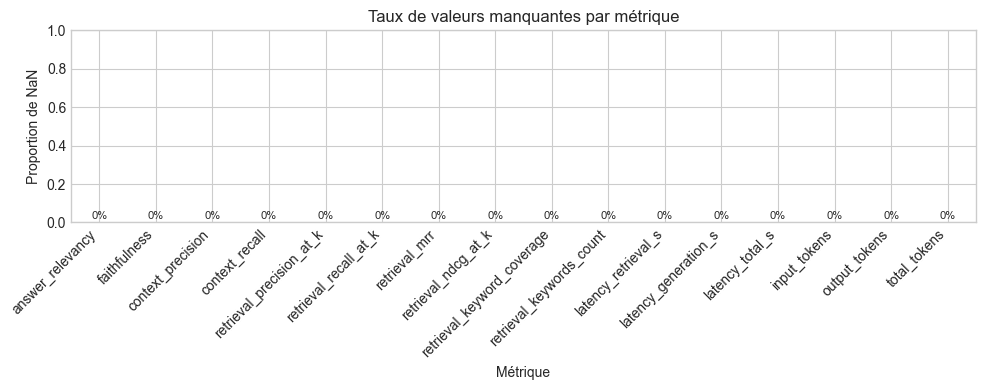

In [73]:
# Complétude / valeurs manquantes
if not all_metrics:
    print("Aucune métrique disponible dans le fichier chargé.")
else:
    na_ratio = df[all_metrics].isna().mean().sort_values(ascending=False)
    comp = pd.DataFrame({
        'na_ratio': na_ratio,
        'non_null_count': df[all_metrics].notna().sum(),
        'non_null_ratio': 1 - na_ratio,
    })
    display(comp)

    display(df[all_metrics].describe().T)

    ax = na_ratio.plot(kind='bar', color='#D55E00', figsize=(10, 4), ylim=(0, 1))
    ax.set_title("Taux de valeurs manquantes par métrique")
    ax.set_ylabel("Proportion de NaN")
    ax.set_xlabel("Métrique")
    for i, v in enumerate(na_ratio.values):
        ax.text(i, min(v + 0.02, 0.98), f"{v:.0%}", ha='center', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


### Lecture méthodologique

- Si la majorité des métriques sont bien renseignées, une lecture relativement complète devient possible.
- Si certaines colonnes sont absentes ou vides, ces dimensions deviennent **ininterprétables** dans ce run.
- Une colonne entièrement vide doit être traitée comme une limite d’évaluation, et non comme un résultat du système.


In [74]:
# Statistiques descriptives robustes (moyenne + médiane + quartiles)
def robust_stats(cols):
    if not cols:
        return pd.DataFrame()
    q = df[cols].quantile([0.25, 0.5, 0.75]).T.rename(columns={0.25: 'q25', 0.5: 'median', 0.75: 'q75'})
    out = pd.DataFrame({
        'mean': df[cols].mean(),
        'min': df[cols].min(),
        'max': df[cols].max(),
    }).join(q, how='left')
    return out[['mean', 'median', 'min', 'q25', 'q75', 'max']].sort_index()

for group_name, cols in available_metrics.items():
    print(f'\n### {group_name}')
    stats_df = robust_stats(cols)
    if stats_df.empty:
        print('Aucune colonne disponible dans ce groupe.')
    else:
        display(stats_df)



### ragas_core


,mean,median,min,q25,q75,max
answer_relevancy,0.848540,0.930813,0.626162,0.75738,0.950284,0.992126
context_precision,0.840909,1.000000,0.250000,0.75000,1.000000,1.000000
context_recall,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
faithfulness,0.954545,1.000000,0.500000,1.00000,1.000000,1.000000



### retrieval


,mean,median,min,q25,q75,max
retrieval_keyword_coverage,0.940909,1.0,0.750000,0.900000,1.0,1.0
retrieval_keywords_count,3.454545,3.0,2.000000,2.500000,4.5,5.0
retrieval_mrr,0.909091,1.0,0.500000,1.000000,1.0,1.0
retrieval_ndcg_at_k,0.917556,1.0,0.548636,0.939501,1.0,1.0
retrieval_precision_at_k,0.490909,0.6,0.200000,0.400000,0.6,0.6
retrieval_recall_at_k,0.940909,1.0,0.750000,0.900000,1.0,1.0



### operational


,mean,median,min,q25,q75,max
input_tokens,853.636364,841.000000,595.000000,758.500000,910.500000,1175.000000
latency_generation_s,0.624561,0.584641,0.493889,0.568434,0.655881,0.837836
latency_retrieval_s,1.480273,1.444353,1.359448,1.385090,1.511777,1.834737
latency_total_s,2.105195,2.073146,1.932645,1.988492,2.119568,2.530002
output_tokens,22.000000,20.000000,5.000000,13.000000,31.500000,46.000000
total_tokens,875.636364,866.000000,641.000000,774.000000,931.000000,1180.000000


La moyenne seule peut masquer des comportements hétérogènes. La médiane et les quartiles permettent de vérifier si la performance est stable ou tirée par quelques cas extrêmes.


## Section RAGAS core

Les métriques cœur RAGAS cherchent à capturer la qualité de la réponse et son ancrage au contexte. Elles sont utiles, mais ne doivent pas être interprétées comme des preuves absolues de vérité ou de robustesse générale hors du protocole d’évaluation.


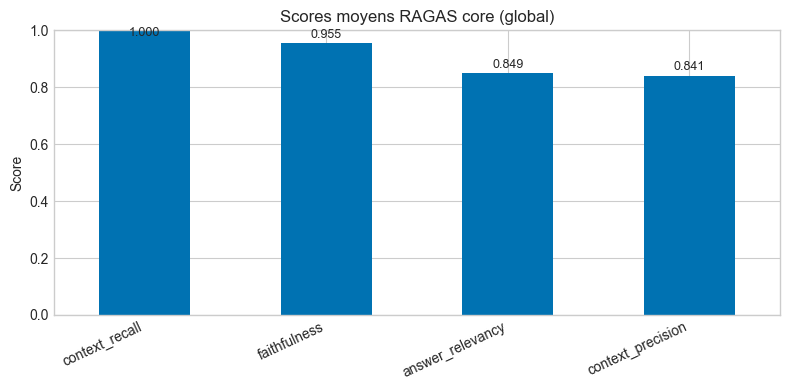

,mean,median,min,q25,q75,max
answer_relevancy,0.848540,0.930813,0.626162,0.75738,0.950284,0.992126
context_precision,0.840909,1.000000,0.250000,0.75000,1.000000,1.000000
context_recall,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
faithfulness,0.954545,1.000000,0.500000,1.00000,1.000000,1.000000


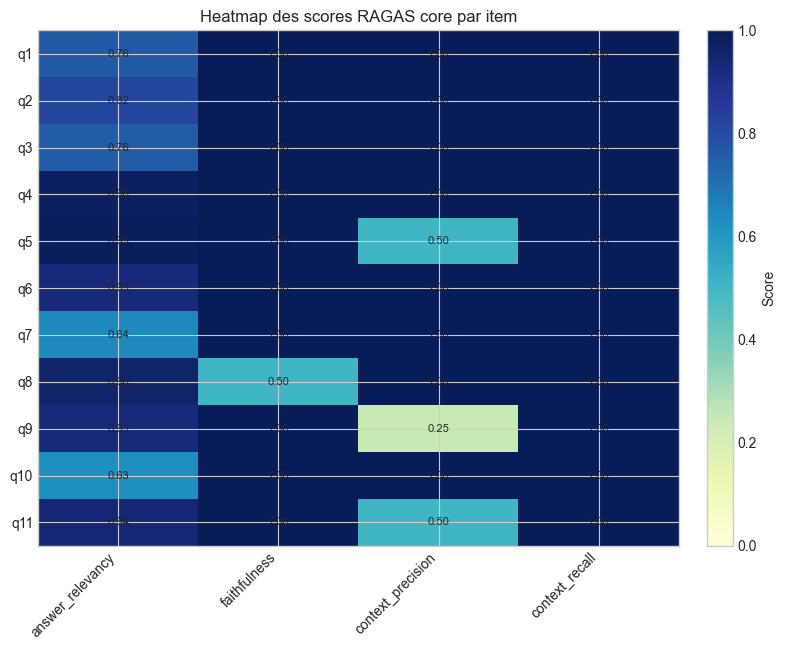

In [75]:
core_metrics = available_metrics['ragas_core']

if not core_metrics:
    print("Aucune métrique RAGAS core disponible.")
else:
    # Moyennes globales
    core_mean = df[core_metrics].mean().sort_values(ascending=False)
    ax = core_mean.plot(kind='bar', color='#0072B2', figsize=(8, 4), ylim=(0, 1))
    ax.set_title("Scores moyens RAGAS core (global)")
    ax.set_ylabel("Score")
    for i, v in enumerate(core_mean.values):
        ax.text(i, min(v + 0.02, 0.98), f"{v:.3f}", ha='center', fontsize=9)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

    # Distribution simple
    display(robust_stats(core_metrics))

    # Heatmap question x métriques core
    if 'id' in df.columns:
        heat = df[['id'] + core_metrics].copy().set_index('id')
    else:
        heat = df[core_metrics].copy()
        heat.index = [f'q{i+1}' for i in range(len(heat))]
        heat.index.name = 'id'

    matrix = heat[core_metrics].fillna(0.0).values
    fig, ax = plt.subplots(figsize=(8, max(3, 0.6 * len(heat))))
    im = ax.imshow(matrix, aspect='auto', cmap='YlGnBu', vmin=0, vmax=1)
    ax.set_xticks(range(len(core_metrics)))
    ax.set_xticklabels(core_metrics, rotation=45, ha='right')
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_title("Heatmap des scores RAGAS core par item")

    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, f"{matrix[r, c]:.2f}", ha='center', va='center', fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Score')
    plt.tight_layout()
    plt.show()


### Lecture critique RAGAS core

Sur ce run, les métriques core sont bonnes mais hétérogènes. `faithfulness` vaut 1.0 sur les 11 items, tandis que `answer_relevancy` (moyenne 0.79, médiane 0.94) et `context_precision` (moyenne 0.70, médiane 1.0, minimum 0.0) montrent qu’un petit nombre de cas faibles tire les moyennes vers le bas.

La lecture cohérente est donc la suivante : le système est souvent bien ancré dans le contexte récupéré lorsqu’il répond, mais il n’est pas homogènement robuste sur tous les items. Le score parfait de fidélité ne suffit pas, à lui seul, à prouver une exactitude métier absolue ni à effacer les cas de rupture visibles dans les autres métriques.


## Section Retrieval (analyse d’un sous-système)

Les métriques retrieval évaluent la capacité à récupérer des contenus pertinents. Elles n’évaluent pas directement la qualité finale de la réponse, mais conditionnent fortement cette qualité.


,mean,median,min,q25,q75,max
retrieval_keyword_coverage,0.940909,1.0,0.750000,0.900000,1.0,1.0
retrieval_keywords_count,3.454545,3.0,2.000000,2.500000,4.5,5.0
retrieval_mrr,0.909091,1.0,0.500000,1.000000,1.0,1.0
retrieval_ndcg_at_k,0.917556,1.0,0.548636,0.939501,1.0,1.0
retrieval_precision_at_k,0.490909,0.6,0.200000,0.400000,0.6,0.6
retrieval_recall_at_k,0.940909,1.0,0.750000,0.900000,1.0,1.0


,mean,median
retrieval_keywords_count,3.454545,3.0
retrieval_recall_at_k,0.940909,1.0
retrieval_keyword_coverage,0.940909,1.0
retrieval_ndcg_at_k,0.917556,1.0
retrieval_mrr,0.909091,1.0
retrieval_precision_at_k,0.490909,0.6


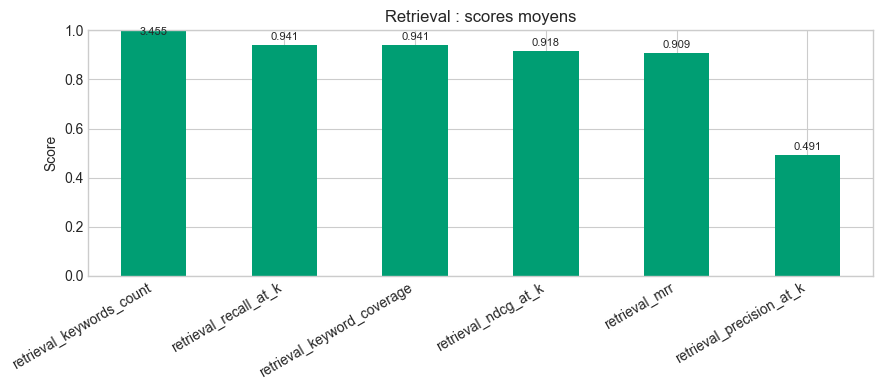

In [76]:
retrieval_metrics = available_metrics['retrieval']

if not retrieval_metrics:
    print("Aucune métrique retrieval disponible.")
else:
    display(robust_stats(retrieval_metrics))

    # Barplot moyenne + médiane
    mean_vals = df[retrieval_metrics].mean().sort_values(ascending=False)
    median_vals = df[retrieval_metrics].median().reindex(mean_vals.index)
    comp_df = pd.DataFrame({'mean': mean_vals, 'median': median_vals})
    display(comp_df)

    ax = mean_vals.plot(kind='bar', color='#009E73', figsize=(9, 4), ylim=(0, 1))
    ax.set_title("Retrieval : scores moyens")
    ax.set_ylabel("Score")
    for i, v in enumerate(mean_vals.values):
        if pd.notna(v):
            ax.text(i, min(v + 0.02, 0.98), f"{v:.3f}", ha='center', fontsize=8)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


### Synthèse méthodologique retrieval

Retrieval et génération doivent être lus ensemble. Ici, le retrieval couvre souvent l’information utile et la place assez tôt dans le classement (`retrieval_recall_at_k` 0.90, `retrieval_mrr` 0.91, `retrieval_ndcg_at_k` 0.89), mais la précision du top-k reste plus faible (`retrieval_precision_at_k` 0.49, médiane 0.6).

La conclusion cohérente n’est donc pas "retrieval excellent" mais plutôt "retrieval globalement couvrant, avec un bruit non négligeable". Cela aide à comprendre pourquoi la fidélité des réponses peut rester élevée alors que certains contexts récupérés sont imparfaitement ciblés.


## Section opérationnelle (latence et tokens)

La qualité d’un système RAG ne se juge pas indépendamment de ses contraintes opérationnelles. Une performance de scoring doit être mise en regard du temps de réponse et de la consommation de tokens.

La dimension coût n’est pas traitée ici, car la métrique de coût est systématiquement vide dans les runs disponibles.


,mean,median,min,q25,q75,max
input_tokens,853.636364,841.000000,595.000000,758.500000,910.500000,1175.000000
latency_generation_s,0.624561,0.584641,0.493889,0.568434,0.655881,0.837836
latency_retrieval_s,1.480273,1.444353,1.359448,1.385090,1.511777,1.834737
latency_total_s,2.105195,2.073146,1.932645,1.988492,2.119568,2.530002
output_tokens,22.000000,20.000000,5.000000,13.000000,31.500000,46.000000
total_tokens,875.636364,866.000000,641.000000,774.000000,931.000000,1180.000000


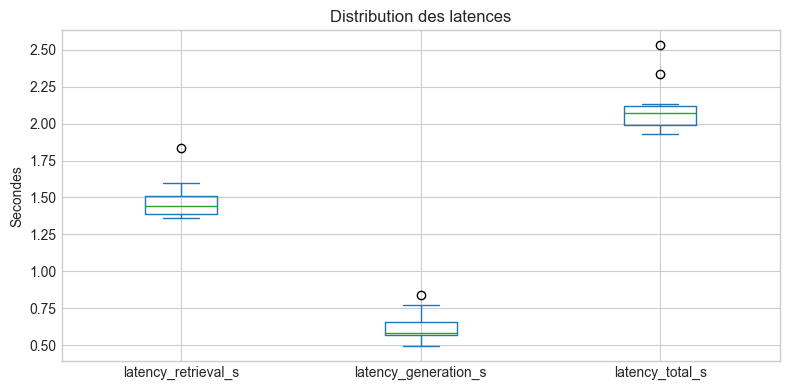

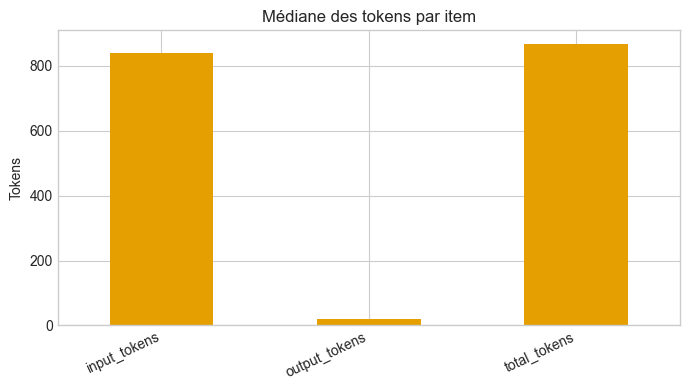

In [77]:
ops_metrics = available_metrics['operational']
if not ops_metrics:
    print("Aucune métrique opérationnelle disponible.")
else:
    display(robust_stats(ops_metrics))

    latency_cols = [c for c in ['latency_retrieval_s', 'latency_generation_s', 'latency_total_s'] if c in df.columns]
    token_cols = [c for c in ['input_tokens', 'output_tokens', 'total_tokens'] if c in df.columns]

    if latency_cols:
        ax = df[latency_cols].plot(kind='box', figsize=(8, 4))
        ax.set_title("Distribution des latences")
        ax.set_ylabel("Secondes")
        plt.tight_layout()
        plt.show()

    if token_cols:
        ax = df[token_cols].median().plot(kind='bar', color='#E69F00', figsize=(7, 4))
        ax.set_title("Médiane des tokens par item")
        ax.set_ylabel("Tokens")
        plt.xticks(rotation=25, ha='right')
        plt.tight_layout()
        plt.show()


### Lecture réflexive opérationnelle

Les métriques de latence et de tokens sont bien observables sur les items évalués, ce qui permet de discuter le compromis qualité / temps de réponse / consommation.

La dimension coût est hors périmètre dans ce notebook, car elle n’est pas exploitable de manière fiable sur les données disponibles.


## Analyse par catégorie

L’analyse par sous-groupes est essentielle : une bonne moyenne globale peut masquer des fragilités localisées. Une évaluation défendable vérifie donc l’homogénéité des performances selon la catégorie de question.


,effectif
category,
complex,5
noisy,1
simple,5


,answer_relevancy,faithfulness,context_precision,context_recall,retrieval_precision_at_k,retrieval_recall_at_k,retrieval_mrr,retrieval_ndcg_at_k,retrieval_keyword_coverage,retrieval_keywords_count
category,,,,,,,,,,
complex,0.913444,0.9,0.75,1.0,0.44,0.87,0.8,0.842822,0.87,4.6
noisy,0.626162,1.0,1.00,1.0,0.60,1.00,1.0,0.971426,1.00,3.0
simple,0.828112,1.0,0.90,1.0,0.52,1.00,1.0,0.981515,1.00,2.4


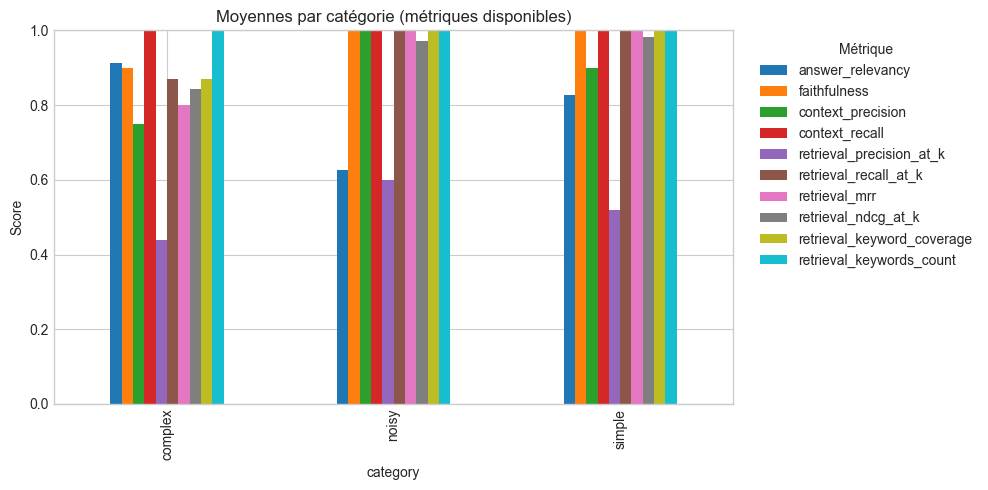

In [78]:
if 'category' not in df.columns:
    print("Colonne 'category' absente : analyse par catégorie impossible.")
else:
    focus_metrics = [m for m in (available_metrics['ragas_core'] + available_metrics['retrieval']) if m in df.columns]

    cat_counts = df.groupby('category', dropna=False).size().rename('effectif').to_frame()
    display(cat_counts)

    if focus_metrics:
        by_cat = df.groupby('category', dropna=False)[focus_metrics].mean().sort_index()
        display(by_cat)

        ax = by_cat.plot(kind='bar', figsize=(10, 5), ylim=(0, 1))
        ax.set_title("Moyennes par catégorie (métriques disponibles)")
        ax.set_ylabel("Score")
        ax.legend(title='Métrique', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune métrique exploitable pour la comparaison par catégorie.")


Les écarts entre catégories sont informatifs pour le pilotage, mais ils doivent être lus avec prudence. Dans ce run, `complex` obtient les meilleurs scores de pertinence de réponse (`answer_relevancy` ~0.96) alors que ses scores de retrieval sont un peu moins propres que ceux de `simple` (`retrieval_precision_at_k` 0.44 contre 0.52 ; `retrieval_ndcg_at_k` 0.83 contre 0.98).

Inversement, la moyenne de `simple` est nettement pénalisée par un échec marqué (`q2`). La catégorie `noisy` ne contient qu’un seul item : elle peut signaler une piste, mais elle ne permet aucune généralisation.


## Analyse des cas faibles et des cas extrêmes

Cette section évite l’écueil d’une lecture centrée uniquement sur les moyennes globales.


In [79]:
core_metrics = available_metrics['ragas_core']
score_proxy_col = 'score_agrege_core_proxy'

if core_metrics:
    work = df.copy()
    work[score_proxy_col] = work[core_metrics].mean(axis=1, skipna=True)

    cols = [c for c in ['id', 'category', score_proxy_col, 'answer_relevancy', 'faithfulness', 'context_precision', 'context_recall'] if c in work.columns]

    print("Pires cas (5 plus faibles scores agrégés core) :")
    display(work[cols].sort_values(score_proxy_col, ascending=True).head(5))

    print("Meilleurs cas (5 plus forts scores agrégés core) :")
    display(work[cols].sort_values(score_proxy_col, ascending=False).head(5))
else:
    print("Aucune métrique core disponible : impossible de construire un score agrégé core proxy.")


Pires cas (5 plus faibles scores agrégés core) :


,id,category,score_agrege_core_proxy,answer_relevancy,faithfulness,context_precision,context_recall
8,q9,complex,0.795660,0.932639,1.0,0.25,1.0
10,q11,complex,0.860219,0.940877,1.0,0.50,1.0
7,q8,complex,0.864923,0.959691,0.5,1.00,1.0
4,q5,simple,0.873032,0.992126,1.0,0.50,1.0
9,q10,noisy,0.906540,0.626162,1.0,1.00,1.0


Meilleurs cas (5 plus forts scores agrégés core) :


,id,category,score_agrege_core_proxy,answer_relevancy,faithfulness,context_precision,context_recall
3,q4,complex,0.994302,0.977208,1.0,1.0,1.0
5,q6,simple,0.982703,0.930813,1.0,1.0,1.0
1,q2,simple,0.954727,0.818908,1.0,1.0,1.0
0,q1,simple,0.939489,0.757956,1.0,1.0,1.0
2,q3,complex,0.939201,0.756804,1.0,1.0,1.0


Les cas faibles sont méthodologiquement centraux, et c’est particulièrement vrai ici. `q2` constitue un échec net avec un score core proxy de 0.25, `answer_relevancy` = 0.0, `context_precision` = 0.0 et `context_recall` = 0.0, alors que plusieurs autres items sont proches de 1 sur l’ensemble des métriques core.

La bonne lecture n’est donc ni "le système échoue globalement" ni "le système est uniformément robuste". Elle est plus précise : la majorité des cas observés sont bien traités, mais au moins un point de rupture clair subsiste et doit être investigué prioritairement.


## Validité et limites de l’évaluation

### 1) Taille de l’échantillon
Le nombre de questions évaluées reste limité à ce qui est présent dans le fichier chargé. Les conclusions doivent donc être proportionnées à cette taille d’échantillon.

### 2) Représentativité des cas
Les résultats reflètent les cas évalués, pas nécessairement l’ensemble des cas métier possibles. Une couverture incomplète peut biaiser la perception de robustesse.

### 3) Dépendance à la qualité des références
Certaines métriques (notamment celles comparées à `reference`) héritent directement de la qualité et de la précision des références. Une référence imparfaite fragilise l’interprétation.

### 4) Limites des métriques automatiques
Les métriques automatiques quantifient des proxys utiles mais ne remplacent pas une validation métier complète.

### 5) Validation humaine
En l’absence de revue humaine systématique, certaines dimensions qualitatives (nuance métier, adéquation contextuelle fine) restent partiellement hors champ.

### 6) Données manquantes
Les colonnes absentes ou partiellement renseignées réduisent le périmètre de ce qui est soutenable dans les conclusions.

### 7) Prudence globale
Les résultats sont informatifs et actionnables, mais ils ne constituent pas une preuve universelle de performance hors du protocole observé.


## Registre des biais potentiels

- **Biais de sélection des questions** : le jeu d’évaluation peut sur- ou sous-représenter certains types de difficultés.
- **Biais de couverture du dataset** : les documents disponibles peuvent favoriser certains sujets et en ignorer d’autres.
- **Biais de formulation des références** : une référence ambiguë ou incomplète peut dégrader artificiellement certaines métriques.
- **Biais d’interprétation des métriques** : surinterpréter un score isolé peut conduire à des conclusions excessives.
- **Biais du juge LLM** : certaines métriques s’appuient sur un jugement automatisé qui peut varier selon le modèle ou le prompt.
- **Confusion fidélité / exactitude** : une réponse fidèle au contexte récupéré n’est pas forcément vraie dans l’absolu.
- **Confusion moyenne / robustesse** : une moyenne élevée peut masquer des échecs localisés mais importants.


In [80]:
# Synthèse dynamique des points d'attention
lines = []

lines.append(f"- Observations évaluées : {len(df)}")
lines.append(f"- Colonnes totales disponibles : {len(df.columns)}")

missing_metrics = []
for group, expected in metric_groups.items():
    missing = [c for c in expected if c not in df.columns]
    if missing:
        missing_metrics.extend(missing)

if missing_metrics:
    lines.append("- Métriques indisponibles : " + ", ".join(sorted(set(missing_metrics))))
else:
    lines.append("- Métriques indisponibles : aucune parmi les métriques attendues du notebook")

partially_observed = [
    c for c in df.columns
    if 0 < df[c].notna().sum() < len(df)
]
if partially_observed:
    lines.append("- Dimensions partiellement observables : " + ", ".join(sorted(partially_observed)))
else:
    lines.append("- Dimensions partiellement observables : aucune")

core_cols = [c for c in ['answer_relevancy', 'faithfulness', 'context_precision', 'context_recall'] if c in df.columns]
if core_cols:
    proxy = df[core_cols].mean(axis=1, skipna=True)
    low_count = int((proxy < 0.5).sum())
    lines.append(f"- Cas potentiellement faibles (score core proxy < 0.5) : {low_count}")
else:
    lines.append("- Cas potentiellement faibles : non calculable (métriques core absentes)")

lines.append("- Dimension coût : exclue de cette évaluation (métrique de coût retirée car vide)")

print("Synthèse automatique des points d'attention :")
for line in lines:
    print(line)


Synthèse automatique des points d'attention :
- Observations évaluées : 11
- Colonnes totales disponibles : 23
- Métriques indisponibles : aucune parmi les métriques attendues du notebook
- Dimensions partiellement observables : aucune
- Cas potentiellement faibles (score core proxy < 0.5) : 0
- Dimension coût : exclue de cette évaluation (métrique de coût retirée car vide)


## Conclusions soutenables et non soutenables

### Ce que l’évaluation permet de soutenir
- Les résultats suggèrent un niveau de performance observable sur les dimensions mesurées dans ce run.
- Les scores sont compatibles avec l’hypothèse d’un comportement globalement cohérent sur les cas évalués.
- Les données disponibles indiquent des points forts et des points faibles exploitables pour le pilotage.

### Ce que l’évaluation ne permet pas, à elle seule, d’établir
- Le notebook ne permet pas de démontrer une robustesse générale sur tous les cas métiers possibles.
- La dimension économique n’est pas établie ici, car la métrique de coût a été retirée faute de données exploitables.
- Ces résultats ne suffisent pas à établir une exactitude absolue hors contexte et hors protocole d’évaluation.
- Une validation humaine complémentaire reste nécessaire pour confirmer certaines conclusions qualitatives.


## Pistes d’amélioration de la démarche d’évaluation

- Élargir le jeu de test pour mieux couvrir la diversité des cas.
- Documenter explicitement la construction des références utilisées pour l’évaluation.
- Ajouter une calibration humaine sur un sous-ensemble de questions critiques.
- Comparer plusieurs versions du système dans un protocole identique.
- Renforcer les analyses par sous-groupes (catégories, types de question, difficulté).
- Compléter la dimension économique lorsque les données de coût sont absentes ou incomplètes.
- Tester la robustesse des conclusions à des variations de configuration (retrieval, modèle juge, paramètres).


### Vérification de cohérence narrative

Le fil méthodologique de ce notebook suit explicitement cette logique :
1. décrire les données disponibles ;
2. expliciter ce que mesurent les métriques ;
3. analyser les résultats ;
4. examiner les cas faibles ;
5. discuter les limites et biais ;
6. formuler des conclusions prudentes ;
7. proposer des améliorations de la démarche d’évaluation.
